In [1]:
%matplotlib inline

import json
import hashlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

import sklearn.metrics as skm
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix, brier_score_loss, log_loss

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.train_balanced_bagging_ensemble import run_balanced_bagging
from src.splits.io import load_splits

from src.eval.plots import (
    plot_roc_curves,
    plot_pr_curves,
    plot_confusion_matrices,
    plot_probability_distributions,
)

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

In [2]:
def apply_split_lists(df: pd.DataFrame, train_list: Path, val_list: Path, test_list: Path, *, split_col: str = "split") -> pd.DataFrame:
    splits = load_splits(train_list, val_list, test_list)

    cap_to_split = {}
    for split_name, caps in splits.items():
        for cid in caps:
            cap_to_split[str(cid)] = split_name

    out = df.copy()
    out["capture_id"] = out["capture_id"].astype(str)
    out[split_col] = out["capture_id"].map(cap_to_split)

    missing_caps = sorted(out.loc[out[split_col].isna(), "capture_id"].unique().tolist())
    if missing_caps:
        raise ValueError(
            f"Found {len(missing_caps)} captures without split assignment. "
            f"Examples: {missing_caps[:10]}"
        )

    return out


def print_split_summary(df: pd.DataFrame, name: str):
    print(f"\n{name} split counts:")
    print(df["split"].value_counts(dropna=False))
    print(f"\n{name} label by split:")
    print(pd.crosstab(df["split"], df["label"]))


def print_capture_summary(df: pd.DataFrame, name: str):
    tmp = (
        df.groupby(["split", "dataset"])["capture_id"]
        .nunique()
        .unstack(fill_value=0)
    )
    print(f"\n{name} unique captures by split/dataset:")
    print(tmp)

In [3]:
logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

# Keep only trainable rows
if "q_min_packets_ok" in vnat_feats.columns:
    vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

# Apply canonical VNAT splits from text files
vnat_feats = apply_split_lists(
    vnat_feats,
    paths.data_splits / "vnat_train_captures.txt",
    paths.data_splits / "vnat_val_captures.txt",
    paths.data_splits / "vnat_test_captures.txt",
)

print_split_summary(vnat_feats, "VNAT")
print_capture_summary(vnat_feats, "VNAT")

2026-03-07 15:08:24 | INFO | ai-vpn-firewall | Re-extracting VNAT features...

VNAT split counts:
split
train    7750
test      210
val       147
Name: count, dtype: int64

VNAT label by split:
label     0    1
split           
test    197   13
train  7401  349
val     135   12

VNAT unique captures by split/dataset:
dataset  vnat
split        
test       26
train     115
val        24


In [4]:
logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

# Keep only trainable rows
if "q_min_packets_ok" in iscx_feats.columns:
    iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

# Require canonical ISCX split files
iscx_train_list = paths.data_splits / "iscx_train_captures.txt"
iscx_val_list   = paths.data_splits / "iscx_val_captures.txt"
iscx_test_list  = paths.data_splits / "iscx_test_captures.txt"

for p in [iscx_train_list, iscx_val_list, iscx_test_list]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing canonical ISCX split file: {p}\n"
            f"Run notebooks/08_iscx_data_processing.ipynb to generate it first."
        )

iscx_feats = apply_split_lists(
    iscx_feats,
    iscx_train_list,
    iscx_val_list,
    iscx_test_list,
)

print_split_summary(iscx_feats, "ISCX")
print_capture_summary(iscx_feats, "ISCX")

2026-03-07 15:08:51 | INFO | ai-vpn-firewall | Re-extracting ISCX features...

ISCX split counts:
split
train    8388
val      1779
test     1634
Name: count, dtype: int64

ISCX label by split:
label     0     1
split            
test   1396   238
train  6359  2029
val    1103   676

ISCX unique captures by split/dataset:
dataset  iscx
split        
test       21
train      98
val        21


In [5]:
df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)

# Normalize just in case
df_all["split"] = (
    df_all["split"]
    .replace({"iscx_train": "train", "iscx_val": "val", "iscx_test": "test"})
    .astype(str)
)

# Keep only valid splits
valid_splits = {"train", "val", "test"}
bad_splits = sorted(set(df_all["split"].unique()) - valid_splits)
if bad_splits:
    raise ValueError(f"Unexpected split values found: {bad_splits}")

print("\nFINAL combined split counts:")
print(df_all["split"].value_counts())

print("\nFINAL combined label by split:")
print(pd.crosstab(df_all["split"], df_all["label"]))

print("\nFINAL combined dataset by split:")
print(pd.crosstab(df_all["split"], df_all["dataset"]))

print("\nFINAL combined unique captures by split/dataset:")
print(
    df_all.groupby(["split", "dataset"])["capture_id"]
    .nunique()
    .unstack(fill_value=0)
)


FINAL combined split counts:
split
train    16138
val       1926
test      1844
Name: count, dtype: int64

FINAL combined label by split:
label      0     1
split             
test    1593   251
train  13760  2378
val     1238   688

FINAL combined dataset by split:
dataset  iscx  vnat
split              
test     1634   210
train    8388  7750
val      1779   147

FINAL combined unique captures by split/dataset:
dataset  iscx  vnat
split              
test       21    26
train      98   115
val        21    24


In [6]:
print("\n" + "=" * 60)
print("LABEL CONSISTENCY CHECK")
print("=" * 60)

print("VNAT VPN label meaning check:")
print(
    vnat_flows[vnat_flows["capture_id"].astype(str).str.startswith("vpn_")]
    .groupby("capture_id")["label"]
    .mean()
    .head(10)
)

print("\nISCX VPN label meaning check:")
print(
    iscx_flows[iscx_flows["capture_id"].astype(str).str.startswith("vpn_")]
    .groupby("capture_id")["label"]
    .mean()
    .head(10)
)

print("=" * 60 + "\n")


LABEL CONSISTENCY CHECK
VNAT VPN label meaning check:
capture_id
vpn_netflix_capture2.pcap    1.0
vpn_rdp_capture1.pcap        1.0
vpn_rdp_capture2.pcap        1.0
vpn_rdp_capture_3.pcap       1.0
vpn_rsync_capture1.pcap      1.0
vpn_rsync_capture2.pcap      1.0
vpn_rsync_capture3.pcap      1.0
vpn_scp_capture1.pcap        1.0
vpn_scp_capture2.pcap        1.0
vpn_sftp_capture1.pcap       1.0
Name: label, dtype: float64

ISCX VPN label meaning check:
capture_id
vpn_vpn_aim_chat1a.pcap         1.0
vpn_vpn_aim_chat1b.pcap         1.0
vpn_vpn_bittorrent.pcap         1.0
vpn_vpn_email2a.pcap            1.0
vpn_vpn_email2b.pcap            1.0
vpn_vpn_facebook_audio2.pcap    1.0
vpn_vpn_facebook_chat1a.pcap    1.0
vpn_vpn_facebook_chat1b.pcap    1.0
vpn_vpn_ftps_a.pcap             1.0
vpn_vpn_ftps_b.pcap             1.0
Name: label, dtype: float64



In [7]:
logger.info("Running pre-flight diagnostics...")

temp_pipe = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feat_cols = temp_pipe.model_feature_names()

print(f"Detected {len(feat_cols)} model features.")
print("First 30 features:", feat_cols[:30])

suspicious = [
    c for c in feat_cols
    if any(x in c.lower() for x in ["id", "label", "split", "pcap", "capture", "file", "dataset"])
]
if suspicious:
    print(f"WARNING: suspicious feature names found: {suspicious}")

X_train_check = temp_pipe.transform(df_all[df_all["split"] == "train"])
variances = X_train_check[feat_cols].var()
zero_var_cols = variances[variances == 0].index.tolist()

if zero_var_cols:
    print(f"WARNING: found {len(zero_var_cols)} zero-variance features: {zero_var_cols}")
else:
    print("No zero-variance model features found.")

2026-03-07 15:09:38 | INFO | ai-vpn-firewall | Running pre-flight diagnostics...
Detected 39 model features.
First 30 features: ['sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min', 'h_size_all_00', 'h_size_all_01', 'h_size_all_02', 'h_size_all_03', 'h_size_all_04', 'h_size_all_05', 'h_size_all_06', 'h_iat_all_00', 'h_iat_all_01', 'h_iat_all_02', 'h_iat_all_03', 'h_iat_all_04']
No zero-variance model features found.


In [8]:
logger.info("Running random label smoke test...")

df_train_check = df_all[df_all["split"] == "train"].copy()
df_test_check = df_all[df_all["split"] == "test"].copy()

print("TRAIN label counts:", np.bincount(df_train_check["label"].astype(int)))
print("TEST label counts:", np.bincount(df_test_check["label"].astype(int)))

aucs = []
X_test_check = temp_pipe.transform(df_test_check)[feat_cols]
y_test_real = df_test_check["label"].astype(int).to_numpy()

for seed in range(20):
    df_noise = df_train_check.copy()
    df_noise["label"] = np.random.default_rng(seed).permutation(df_noise["label"].values)

    X_noise = temp_pipe.transform(df_noise)[feat_cols]
    y_noise = df_noise["label"].astype(int)

    model_noise = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        eval_metric="logloss",
        random_state=seed,
        n_jobs=1
    )
    model_noise.fit(X_noise, y_noise)

    preds = model_noise.predict_proba(X_test_check)[:, 1]
    score = skm.roc_auc_score(y_test_real, preds)
    aucs.append(score)

    if seed == 0:
        auc_inv = skm.roc_auc_score(y_test_real, 1 - preds)
        print(f"DEBUG (seed 0): AUC(p)={score:.4f}, AUC(1-p)={auc_inv:.4f}")

print(f"Random Label AUCs (Test): {aucs}")
print(f"Mean Random Label AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}")

2026-03-07 15:09:38 | INFO | ai-vpn-firewall | Running random label smoke test...
TRAIN label counts: [13760  2378]
TEST label counts: [1593  251]
DEBUG (seed 0): AUC(p)=0.3939, AUC(1-p)=0.6061
Random Label AUCs (Test): [0.39392586590236667, 0.4793794064170187, 0.4453422968515142, 0.43346388457469553, 0.47871414530203105, 0.4091718499511058, 0.5000575225776117, 0.6503027438269522, 0.4091468401347529, 0.3629261985329242, 0.35667749591714754, 0.362654842025495, 0.43406912213043625, 0.3880273007155309, 0.45896514381894893, 0.5357452800224087, 0.5816983165892613, 0.38277023731814735, 0.4793581480731187, 0.5287612888058563]
Mean Random Label AUC: 0.4536 +/- 0.0759


In [9]:
logger.info("Running robust capture holdout test (GroupKFold on TRAIN split only)...")

df_train_only = df_all[df_all["split"] == "train"].copy()
gkf = GroupKFold(n_splits=5)

holdout_aucs = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(df_train_only, groups=df_train_only["capture_id"])):
    df_tr = df_train_only.iloc[tr_idx].copy()
    df_te = df_train_only.iloc[te_idx].copy()

    if df_te["label"].nunique() < 2:
        print(f"Fold {fold}: skipped (only 1 class in test)")
        continue

    pipe_ho = FeaturePipeline().fit(df_tr)
    ho_feats = pipe_ho.model_feature_names()

    X_tr = pipe_ho.transform(df_tr)[ho_feats]
    X_te = pipe_ho.transform(df_te)[ho_feats]

    model_ho = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42 + fold
    )
    model_ho.fit(X_tr, df_tr["label"].astype(int))

    p = model_ho.predict_proba(X_te)[:, 1]
    auc = skm.roc_auc_score(df_te["label"].astype(int), p)
    holdout_aucs.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")

if holdout_aucs:
    print(f"GroupKFold AUC mean±std: {np.mean(holdout_aucs):.4f} +/- {np.std(holdout_aucs):.4f}")
else:
    print("WARNING: no valid holdout runs completed.")

2026-03-07 15:09:47 | INFO | ai-vpn-firewall | Running robust capture holdout test (GroupKFold on TRAIN split only)...
Fold 0: AUC = 0.9791
Fold 1: AUC = 0.9989
Fold 2: AUC = 0.9806
Fold 3: AUC = 0.9939
Fold 4: AUC = 0.9986
GroupKFold AUC mean±std: 0.9902 +/- 0.0087


In [10]:
logger.info("Running VNAT -> ISCX smoke test...")

vnat_train_only = df_all[(df_all["dataset"] == "vnat") & (df_all["split"] == "train")].copy()
iscx_test_only = df_all[(df_all["dataset"] == "iscx") & (df_all["split"] == "test")].copy()

if len(vnat_train_only) > 0 and len(iscx_test_only) > 0:
    pipe_cross = FeaturePipeline().fit(vnat_train_only)
    cross_feats = pipe_cross.model_feature_names()

    X_cross_train = pipe_cross.transform(vnat_train_only)[cross_feats]
    X_cross_test = pipe_cross.transform(iscx_test_only)[cross_feats]

    print("DEBUG Cross-Domain:")
    print("VNAT train shape:", X_cross_train.shape)
    print("ISCX test shape:", X_cross_test.shape)
    print("ISCX test label counts:", np.bincount(iscx_test_only["label"].astype(int)))

    model_cross = xgb.XGBClassifier(
        n_estimators=30,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42
    )
    model_cross.fit(X_cross_train, vnat_train_only["label"].astype(int))

    preds_cross = model_cross.predict_proba(X_cross_test)[:, 1]

    auc_cross = skm.roc_auc_score(iscx_test_only["label"].astype(int), preds_cross)
    auc_cross_inv = skm.roc_auc_score(iscx_test_only["label"].astype(int), 1 - preds_cross)

    print(f"VNAT -> ISCX AUC: {auc_cross:.4f}")
    print(f"VNAT -> ISCX AUC(1-p): {auc_cross_inv:.4f}")

    if auc_cross_inv > 0.60:
        print("WARNING: inverted AUC is high. Check label/domain alignment.")

2026-03-07 15:09:49 | INFO | ai-vpn-firewall | Running VNAT -> ISCX smoke test...
DEBUG Cross-Domain:
VNAT train shape: (7750, 39)
ISCX test shape: (1634, 39)
ISCX test label counts: [1396  238]
VNAT -> ISCX AUC: 0.1613
VNAT -> ISCX AUC(1-p): 0.8387


In [11]:
print("\n" + "=" * 60)
print("ADVANCED ROBUSTNESS EVALUATION")
print("=" * 60)

for dataset_name in ["vnat", "iscx"]:
    print(f"\n--- {dataset_name.upper()} GroupKFold (Train Split Only) ---")
    df_ds = df_all[(df_all["dataset"] == dataset_name) & (df_all["split"] == "train")].copy()

    if df_ds.empty:
        print(f"No train data for {dataset_name}")
        continue

    gkf_ds = GroupKFold(n_splits=5)
    ds_aucs = []

    for fold, (tr_idx, te_idx) in enumerate(gkf_ds.split(df_ds, groups=df_ds["capture_id"])):
        df_tr = df_ds.iloc[tr_idx].copy()
        df_te = df_ds.iloc[te_idx].copy()

        if df_te["label"].nunique() < 2:
            continue

        pipe_ds = FeaturePipeline().fit(df_tr)
        feats_ds = pipe_ds.model_feature_names()

        X_tr = pipe_ds.transform(df_tr)[feats_ds]
        X_te = pipe_ds.transform(df_te)[feats_ds]

        model_ds = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=3,
            eval_metric="auc",
            n_jobs=1,
            random_state=42
        )
        model_ds.fit(X_tr, df_tr["label"].astype(int))

        p = model_ds.predict_proba(X_te)[:, 1]
        ds_aucs.append(skm.roc_auc_score(df_te["label"].astype(int), p))

    if ds_aucs:
        print(f"{dataset_name.upper()} GroupKFold AUC: {np.mean(ds_aucs):.4f} +/- {np.std(ds_aucs):.4f}")


ADVANCED ROBUSTNESS EVALUATION

--- VNAT GroupKFold (Train Split Only) ---
VNAT GroupKFold AUC: 0.9998 +/- 0.0003

--- ISCX GroupKFold (Train Split Only) ---
ISCX GroupKFold AUC: 0.9894 +/- 0.0124


In [12]:
print("\n--- Bidirectional Cross-Domain Test (Full Dataset) ---")

vnat_full = df_all[df_all["dataset"] == "vnat"].copy()
iscx_full = df_all[df_all["dataset"] == "iscx"].copy()

if not vnat_full.empty and not iscx_full.empty:
    pipe_v2i = FeaturePipeline().fit(vnat_full)
    feats_v2i = pipe_v2i.model_feature_names()

    model_v2i = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        eval_metric="auc",
        n_jobs=4,
        random_state=42
    )
    model_v2i.fit(pipe_v2i.transform(vnat_full)[feats_v2i], vnat_full["label"].astype(int))
    p_iscx = model_v2i.predict_proba(pipe_v2i.transform(iscx_full)[feats_v2i])[:, 1]
    auc_v2i = skm.roc_auc_score(iscx_full["label"].astype(int), p_iscx)
    print(f"Train VNAT (All) -> Test ISCX (All): AUC = {auc_v2i:.4f}")

    pipe_i2v = FeaturePipeline().fit(iscx_full)
    feats_i2v = pipe_i2v.model_feature_names()

    model_i2v = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        eval_metric="auc",
        n_jobs=4,
        random_state=42
    )
    model_i2v.fit(pipe_i2v.transform(iscx_full)[feats_i2v], iscx_full["label"].astype(int))
    p_vnat = model_i2v.predict_proba(pipe_i2v.transform(vnat_full)[feats_i2v])[:, 1]
    auc_i2v = skm.roc_auc_score(vnat_full["label"].astype(int), p_vnat)
    print(f"Train ISCX (All) -> Test VNAT (All): AUC = {auc_i2v:.4f}")


--- Bidirectional Cross-Domain Test (Full Dataset) ---
Train VNAT (All) -> Test ISCX (All): AUC = 0.3607
Train ISCX (All) -> Test VNAT (All): AUC = 0.8038


In [13]:
print("\n--- Application Holdout (Leave-One-App-Out) ---")

def make_capture_to_app_map(flows: pd.DataFrame) -> pd.Series:
    if "app" not in flows.columns:
        return pd.Series(dtype=str)

    def mode_or_unknown(x):
        x = x.dropna()
        if len(x) == 0:
            return "unknown"
        return x.value_counts().idxmax()

    return flows.groupby("capture_id")["app"].apply(mode_or_unknown)

cap2app_vnat = make_capture_to_app_map(vnat_flows)
cap2app_iscx = make_capture_to_app_map(iscx_flows)
cap2app = pd.concat([cap2app_vnat, cap2app_iscx])

df_all["app"] = df_all["capture_id"].map(cap2app).fillna("unknown")

df_all["app"] = (
    df_all["app"].astype(str)
    .str.lower()
    .str.strip()
    .replace({
        "skype_video": "skype",
        "skype_audio": "skype",
        "facebook_audio": "facebook",
        "facebook_chat": "facebook",
        "aim_chat": "aim",
        "icq_chat": "icq",
        "gmail_chat": "gmail",
        "hangouts_chat": "hangouts",
    }, regex=True)
)

df_all.loc[df_all["app"].str.contains("skype"), "app"] = "skype"
df_all.loc[df_all["app"].str.contains("facebook"), "app"] = "facebook"
df_all.loc[df_all["app"].str.contains("netflix"), "app"] = "netflix"
df_all.loc[df_all["app"].str.contains("youtube"), "app"] = "youtube"
df_all.loc[df_all["app"].str.contains("spotify"), "app"] = "spotify"
df_all.loc[df_all["app"].str.contains("vimeo"), "app"] = "vimeo"
df_all.loc[df_all["app"].str.contains("bittorrent"), "app"] = "bittorrent"

df_train_loao = df_all[df_all["split"] == "train"].copy()
apps = sorted([a for a in df_train_loao["app"].unique() if a != "unknown"])

MIN_N = 200
MIN_POS = 20

loao_results = []

print(f"Testing {len(apps)} apps: {apps}")

for holdout_app in apps:
    train_df = df_train_loao[df_train_loao["app"] != holdout_app].copy()
    test_df = df_train_loao[df_train_loao["app"] == holdout_app].copy()

    if len(test_df) < MIN_N:
        continue

    n_pos = int(test_df["label"].sum())
    n_neg = int((test_df["label"] == 0).sum())

    if n_pos < MIN_POS or n_neg < MIN_POS:
        continue

    pipe_loao = FeaturePipeline().fit(train_df)
    feats_loao = pipe_loao.model_feature_names()

    X_tr = pipe_loao.transform(train_df)[feats_loao]
    y_tr = train_df["label"].astype(int)

    X_te = pipe_loao.transform(test_df)[feats_loao]
    y_te = test_df["label"].astype(int)

    model_loao = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        random_state=42,
        n_jobs=4,
    )
    model_loao.fit(X_tr, y_tr)

    p = model_loao.predict_proba(X_te)[:, 1]
    auc = skm.roc_auc_score(y_te, p)
    ap = skm.average_precision_score(y_te, p)

    loao_results.append({
        "app": holdout_app,
        "n_test": len(test_df),
        "pos_rate": float(y_te.mean()),
        "auc": float(auc),
        "ap": float(ap),
    })

if loao_results:
    res_df = pd.DataFrame(loao_results).sort_values("auc")
    print("\nLeave-One-App-Out Results (Worst 5):")
    print(res_df.head(5).to_string(index=False))
    print(f"\nMacro Mean AUC: {res_df['auc'].mean():.4f}")
    print(f"Macro Mean AP:  {res_df['ap'].mean():.4f}")
else:
    print("No valid LOAO runs passed the filters.")

print("=" * 60 + "\n")


--- Application Holdout (Leave-One-App-Out) ---
Testing 47 apps: ['aim', 'email2a', 'facebook', 'ftps', 'hangouts', 'icq', 'netflix', 'nonaim', 'nonaimchat1', 'nonaimchat2', 'nonemail1a', 'nonemail1b', 'nonemail2a', 'nonemail2b', 'nonftps', 'nongmailchat1', 'nongmailchat2', 'nongmailchat3', 'nonhangout', 'nonhangouts', 'nonicq', 'nonscp1', 'nonscpdown1', 'nonscpdown2', 'nonscpdown3', 'nonscpdown4', 'nonscpdown5', 'nonscpdown6', 'nonscpup1', 'nonscpup3', 'nonscpup5', 'nonsftp', 'nonsftpdown1', 'nonsftpup1', 'nonvoipbuster', 'nonvoipbuster1b', 'nonvoipbuster2b', 'rdp', 'rsync', 'scp', 'sftp', 'skype', 'spotify', 'ssh', 'vimeo', 'voip', 'youtube']

Leave-One-App-Out Results (Worst 5):
     app  n_test  pos_rate      auc       ap
   skype    2750  0.286182 0.934093 0.907827
 youtube     682  0.252199 0.946831 0.879807
facebook    1413  0.183298 0.978671 0.931878
   vimeo    1516  0.071240 0.983948 0.958539
 netflix     447  0.299776 0.996996 0.995394

Macro Mean AUC: 0.9730
Macro Mean AP:

In [14]:
logger.info("Fitting and saving FeaturePipeline on TRAIN split only...")

pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))

feature_cols = pipeline.model_feature_names()
logger.info(f"Pipeline saved. Model features: {len(feature_cols)}")
print("Model feature count:", len(feature_cols))
print("First 30 model features:", feature_cols[:30])

2026-03-07 15:09:56 | INFO | ai-vpn-firewall | Fitting and saving FeaturePipeline on TRAIN split only...
2026-03-07 15:09:56 | INFO | ai-vpn-firewall | Pipeline saved. Model features: 39
Model feature count: 39
First 30 model features: ['sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min', 'h_size_all_00', 'h_size_all_01', 'h_size_all_02', 'h_size_all_03', 'h_size_all_04', 'h_size_all_05', 'h_size_all_06', 'h_iat_all_00', 'h_iat_all_01', 'h_iat_all_02', 'h_iat_all_03', 'h_iat_all_04']


In [15]:
logger.info("\n" + "=" * 60 + "\nRunning Balanced Bagging Ensemble Training...")
logger.info("Transforming features for training...")

df_transformed = pipeline.transform(df_all)

# Add back metadata needed by the trainer/evaluation
for col in ["label", "split", "capture_id", "dataset", "flow_id"]:
    df_transformed[col] = df_all[col].values

print("Transformed shape:", df_transformed.shape)
print("Split counts in transformed DF:")
print(df_transformed["split"].value_counts())

print("\nDataset by split in transformed DF:")
print(pd.crosstab(df_transformed["split"], df_transformed["dataset"]))

2026-03-07 15:09:56 | INFO | ai-vpn-firewall | 
Running Balanced Bagging Ensemble Training...
2026-03-07 15:09:56 | INFO | ai-vpn-firewall | Transforming features for training...
Transformed shape: (19908, 45)
Split counts in transformed DF:
split
train    16138
val       1926
test      1844
Name: count, dtype: int64

Dataset by split in transformed DF:
dataset  iscx  vnat
split              
test     1634   210
train    8388  7750
val      1779   147


In [16]:
results = run_balanced_bagging(
    df=df_transformed,
    label_col="label",
    group_col="capture_id",
    dataset_col="dataset",
    split_col="split",
    bags_per_family=3,
    majority_ratio=1.0,
    target_fprs="0.001,0.005,0.01",
    seed=42,
    output_dir=str(paths.artifacts_dir / "balanced_bagging"),
    model_types=["xgb", "lgbm", "cat"],
    feature_cols=feature_cols,
    weight_xgb=1.0,
    weight_lgbm=1.0,
    weight_cat=1.0,
)

In [17]:
print("\n" + "=" * 60)
print("BALANCED BAGGING RESULTS SUMMARY")
print("=" * 60)

# Helper to print metrics for a specific mode (raw, isotonic, platt)
def print_mode_metrics(mode_name, results_dict):
    print(f"\n>>> MODE: {mode_name.upper()} <<<")

    if mode_name not in results_dict:
        print("  (No metrics found)")
        return

    mode_res = results_dict[mode_name]

    # Print Val and Test Overall
    for split_key in ["val", "test_overall"]:
        if split_key in mode_res:
            m = mode_res[split_key]
            print(f"\n  --- {split_key.upper()} ---")
            if "auc" in m and m["auc"] is not None:
                print(f"  ROC AUC: {m['auc']:.4f}")
            if "pr_auc" in m and m["pr_auc"] is not None:
                print(f"  PR AUC:  {m['pr_auc']:.4f}")

            # Print thresholds
            for key, val in m.items():
                if key.startswith("fpr_"):
                    print(f"    Policy: {key}")
                    print(f"      Threshold: {val['threshold']:.4f}")
                    print(f"      Recall:    {val['recall']:.4f}")
                    print(f"      Precision: {val['precision']:.4f}")
                    print(f"      FPR:       {val['fpr']:.5f}")

# Print for all 3 modes
for mode in ["raw", "isotonic", "platt"]:
    print_mode_metrics(mode, results)

print("\n" + "=" * 60)


BALANCED BAGGING RESULTS SUMMARY

>>> MODE: RAW <<<

  --- VAL ---
  ROC AUC: 0.9811
  PR AUC:  0.9768
    Policy: fpr_0.001
      Threshold: 0.8542
      Recall:    0.8212
      Precision: 0.9965
      FPR:       0.00162
    Policy: fpr_0.005
      Threshold: 0.7649
      Recall:    0.8314
      Precision: 0.9879
      FPR:       0.00565
    Policy: fpr_0.01
      Threshold: 0.7041
      Recall:    0.8416
      Precision: 0.9780
      FPR:       0.01050

  --- TEST_OVERALL ---
  ROC AUC: 0.9457
  PR AUC:  0.8631
    Policy: fpr_0.001
      Threshold: 0.8542
      Recall:    0.5179
      Precision: 0.9924
      FPR:       0.00063
    Policy: fpr_0.005
      Threshold: 0.7649
      Recall:    0.5976
      Precision: 0.9494
      FPR:       0.00502
    Policy: fpr_0.01
      Threshold: 0.7041
      Recall:    0.6255
      Precision: 0.9401
      FPR:       0.00628

>>> MODE: ISOTONIC <<<

  --- VAL ---
  ROC AUC: 0.9847
  PR AUC:  0.9745
    Policy: fpr_0.001
      Threshold: 0.7292
   


Predictions columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']

CALIBRATION COMPARISON (Raw vs Isotonic vs Platt)

--- SPLIT: VAL ---
    Mode    AUC  PR_AUC  Brier  LogLoss
     Raw 0.9811  0.9768 0.0423   0.1504
Isotonic 0.9847  0.9745 0.0380   0.1278
   Platt 0.9811  0.9768 0.0440   0.1654

--- SPLIT: TEST ---
    Mode    AUC  PR_AUC  Brier  LogLoss
     Raw 0.9457  0.8631 0.0439   0.1599
Isotonic 0.9474  0.8402 0.0402   0.1804
   Platt 0.9457  0.8631 0.0468   0.1763

RELIABILITY DIAGRAMS


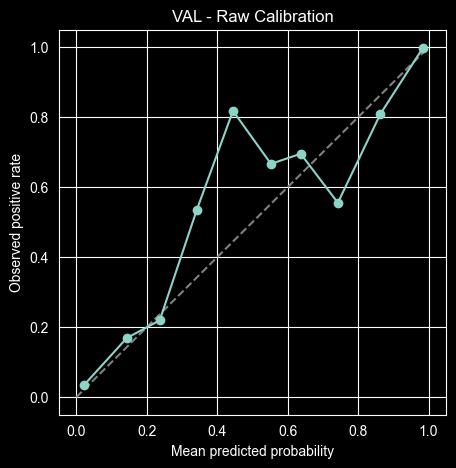

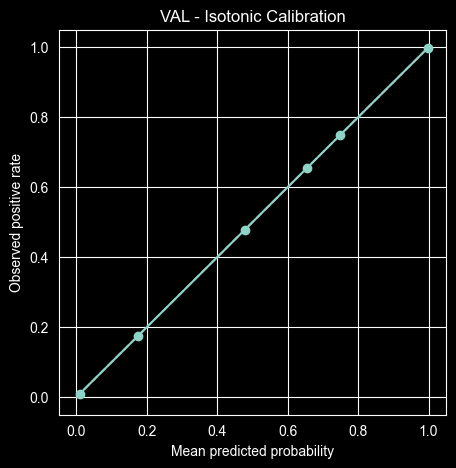

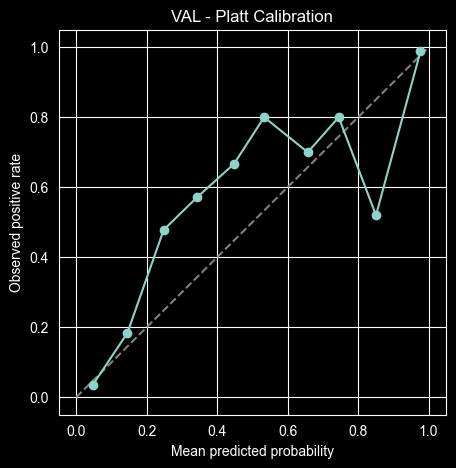

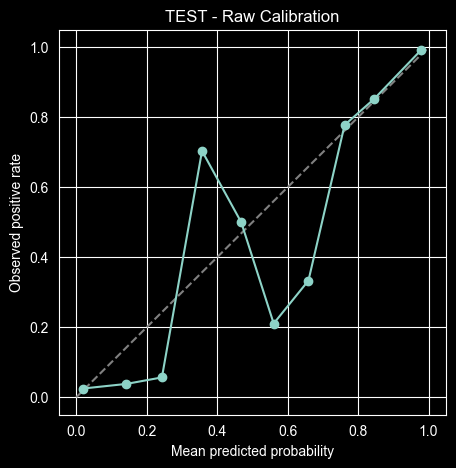

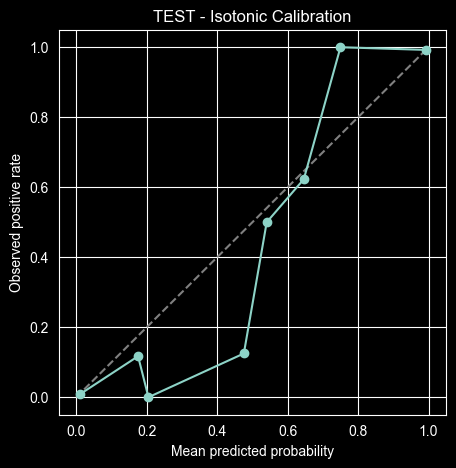

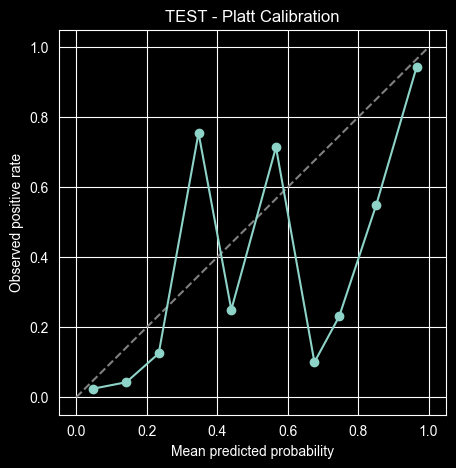


CONFUSION MATRICES (Test Set)

>>> MODE: RAW <<<


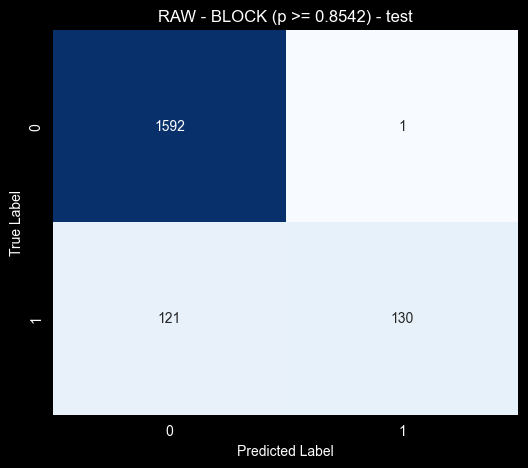

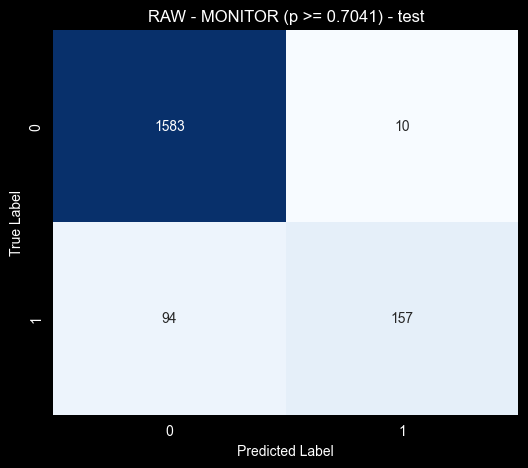


>>> MODE: ISOTONIC <<<


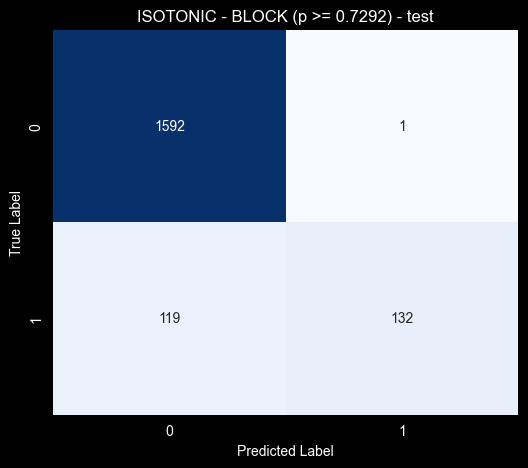

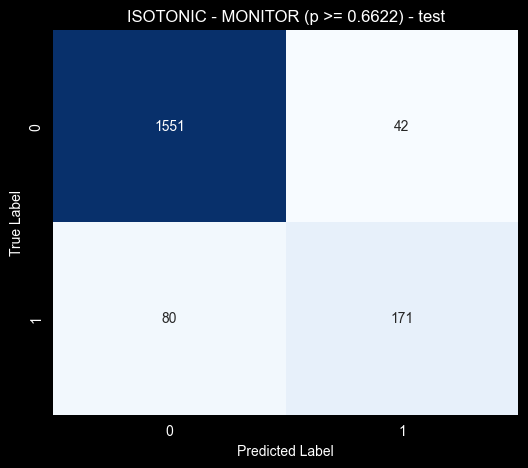


>>> MODE: PLATT <<<


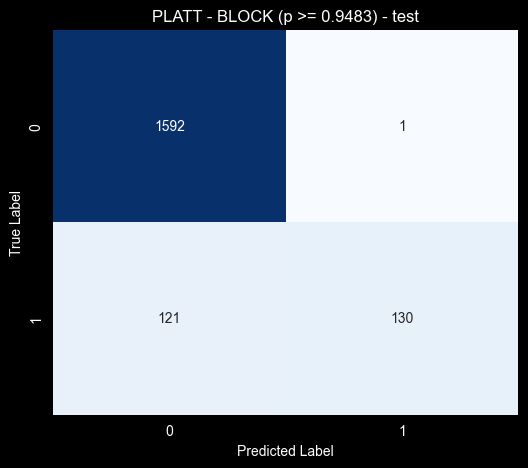

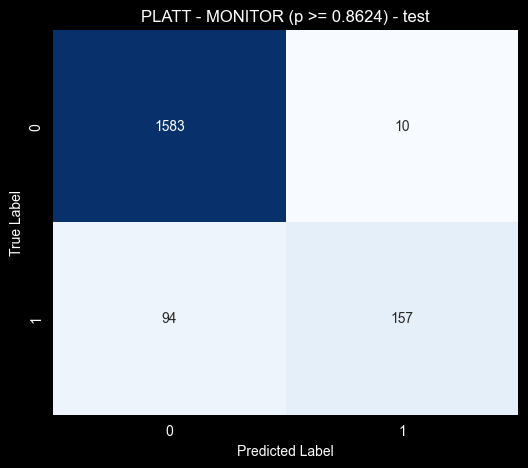

In [18]:
preds_path = paths.artifacts_dir / "balanced_bagging" / "predictions.csv"

if preds_path.exists():
    df_preds = pd.read_csv(preds_path)

    # Check for required columns
    required_cols = ["prob_raw", "prob_iso", "prob_platt"]
    missing = [c for c in required_cols if c not in df_preds.columns]
    if missing:
        raise ValueError(f"Missing probability columns in predictions.csv: {missing}")

    print("\nPredictions columns:")
    print(df_preds.columns.tolist())

    # ----------------------------
    # Comparison: Raw vs Isotonic vs Platt
    # ----------------------------
    print("\n" + "="*60)
    print("CALIBRATION COMPARISON (Raw vs Isotonic vs Platt)")
    print("="*60)

    for split_name in ["val", "test"]:
        sub = df_preds[df_preds["split"] == split_name].copy()
        if sub.empty:
            continue

        y = sub["label"].astype(int)

        print(f"\n--- SPLIT: {split_name.upper()} ---")

        stats = []
        for mode, col in [("Raw", "prob_raw"), ("Isotonic", "prob_iso"), ("Platt", "prob_platt")]:
            p = sub[col]
            auc = roc_auc_score(y, p)
            ap = average_precision_score(y, p)
            brier = brier_score_loss(y, p)
            ll = log_loss(y, np.clip(p, 1e-6, 1 - 1e-6))

            stats.append({
                "Mode": mode,
                "AUC": auc,
                "PR_AUC": ap,
                "Brier": brier,
                "LogLoss": ll
            })

        print(pd.DataFrame(stats).to_string(index=False, float_format="%.4f"))

    # ----------------------------
    # Reliability Diagrams (6 plots)
    # ----------------------------
    def plot_reliability_curve(y_true, y_prob, n_bins=10, title="Reliability Diagram"):
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        bin_ids = np.digitize(y_prob, bins) - 1
        bin_ids = np.clip(bin_ids, 0, n_bins - 1)

        pred_means = []
        obs_rates = []
        counts = []

        for b in range(n_bins):
            mask = bin_ids == b
            if mask.sum() == 0:
                continue
            pred_means.append(y_prob[mask].mean())
            obs_rates.append(y_true[mask].mean())
            counts.append(mask.sum())

        plt.figure(figsize=(5, 5))
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.plot(pred_means, obs_rates, marker="o")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Observed positive rate")
        plt.title(title)
        plt.grid(True)
        plt.show()

    print("\n" + "="*60)
    print("RELIABILITY DIAGRAMS")
    print("="*60)

    for split_name in ["val", "test"]:
        sub = df_preds[df_preds["split"] == split_name]
        y = sub["label"].astype(int)

        for mode, col in [("Raw", "prob_raw"), ("Isotonic", "prob_iso"), ("Platt", "prob_platt")]:
            plot_reliability_curve(
                y,
                sub[col],
                title=f"{split_name.upper()} - {mode} Calibration"
            )

    # ----------------------------
    # Confusion Matrices at Policy Thresholds
    # ----------------------------
    print("\n" + "="*60)
    print("CONFUSION MATRICES (Test Set)")
    print("="*60)

    # Load thresholds from metrics.json to ensure we use the correct ones for each mode
    with open(paths.artifacts_dir / "balanced_bagging" / "metrics.json", "r") as f:
        metrics_loaded = json.load(f)

    test_preds = df_preds[df_preds["split"] == "test"].copy()

    for mode, col in [("raw", "prob_raw"), ("isotonic", "prob_iso"), ("platt", "prob_platt")]:
        print(f"\n>>> MODE: {mode.upper()} <<<")

        # Get thresholds for this mode (tuned on val)
        # Structure: metrics[mode]['val']['fpr_0.001']['threshold']
        val_metrics = metrics_loaded.get(mode, {}).get("val", {})

        def get_thr(m_dict, fpr):
            key = f"fpr_{fpr}"
            if key in m_dict: return m_dict[key]["threshold"]
            return 0.99

        t_block = get_thr(val_metrics, 0.001)
        t_monitor = get_thr(val_metrics, 0.01)

        plot_confusion_matrices(
            test_preds,
            prob_col=col,
            threshold=t_block,
            title=f"{mode.upper()} - BLOCK (p >= {t_block:.4f})"
        )

        plot_confusion_matrices(
            test_preds,
            prob_col=col,
            threshold=t_monitor,
            title=f"{mode.upper()} - MONITOR (p >= {t_monitor:.4f})"
        )

else:
    print("Predictions file not found, skipping plots.")